In [5]:
#Importar librerias 
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.plot
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.pyplot import plot
import os

In [6]:
# Subir un nivel (sale de /scripts)
base_dir = os.path.dirname(os.getcwd())

# Fijar como directorio de trabajo
os.chdir(base_dir)
os.getcwd()

'd:\\AGROSAVIA - CORPORACION COLOMBIANA DE INVESTIGACION AGROPECUARIA\\CAMILO IGNACIO JARAMILLO BARRIOS - Asesoría Estadística Cacao La Suiza'

In [7]:
# Load occurrences
fincas = pd.read_csv("Mapa fincas/Occs_fincas.csv", sep=";")

# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(fincas["LONGITUDE"], fincas["LATITUDE"])]

occ = gpd.GeoDataFrame(
    fincas,
    geometry=geometry,
    crs="EPSG:4326"
)

print(occ.head())


   ID  ID_INTERVIEW MUNICIPALITY    FARM_NAME  LATITUDE  LONGITUDE  \
0   1             5      Lebrija      La Loma  7.167556 -73.272556   
1   1           119    El Carmen   Totomillos  6.765667 -73.519000   
2   2            31      Lebrija  La Macarena  7.106306 -73.272667   
3   3            33      Lebrija   Los Alamos  7.156361 -73.252250   
4   4            34      Lebrija    Villa Luz  7.150083 -73.250167   

                    geometry  
0  POINT (-73.27256 7.16756)  
1    POINT (-73.519 6.76567)  
2  POINT (-73.27267 7.10631)  
3  POINT (-73.25225 7.15636)  
4  POINT (-73.25017 7.15008)  


In [12]:
# Load DEM

dem = rasterio.open("Mapa fincas/elev.tif")

#  Load municipalities shapefile
mun = gpd.read_file("Mapa fincas\Servicios_Públicos_-_Municipios_2005.shp")

# Filter departments
depto = ["SANTANDER"]

mun_SANT = mun[mun["DEPTO"].isin(depto)]

# Dissolve municipalities by department (opcional)
deptos_shp = mun_SANT.dissolve(by="DEPTO")

#aSEGURAR QUE LOS SISTEMAS DE REFERENCIA DE COORDENADAS SEAN LOS MISMOS
mun_SANT = mun_SANT.to_crs(epsg=4326)
deptos_shp = deptos_shp.to_crs(epsg=4326)


<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\pbermeo\AppData\Local\Temp\ipykernel_12968\1895885252.py:7: SyntaxWarning: invalid escape sequence '\S'
  mun = gpd.read_file("Mapa fincas\Servicios_Públicos_-_Municipios_2005.shp")


     OBJECTID_1 DPTO_CCDGO MPIO_CCDGO  Shape_Leng  OBJECTID MPIO_CNMBR  \
971         972         68        013    0.475810       246     AGUADA   
972         973         68        020    0.876130       247    ALBANIA   
973         974         68        051    0.674692       248    ARATOCA   
974         975         68        077    0.270342       249    BARBOSA   
975         976         68        079    0.561089       250  BARICHARA   

       DESCRPCION      DEPTO  P_ENERSI  P_ENERNO  ...  P_ACUENO  P_GASNSI  \
971  AREA # 68013  SANTANDER     352.0     137.0  ...       117         0   
972  AREA # 68020  SANTANDER    1067.0     189.0  ...       468        86   
973  AREA # 68051  SANTANDER    1589.0     132.0  ...       747         0   
974  AREA # 68077  SANTANDER    6622.0     100.0  ...       666       263   
975  AREA # 68079  SANTANDER    1713.0      95.0  ...       340         0   

     P_GASNNO  P_GASNNOIN  P_TELEFSI  P_TELEFNO  P_TELEFNOI    ShapeSTAre  \
971       489  

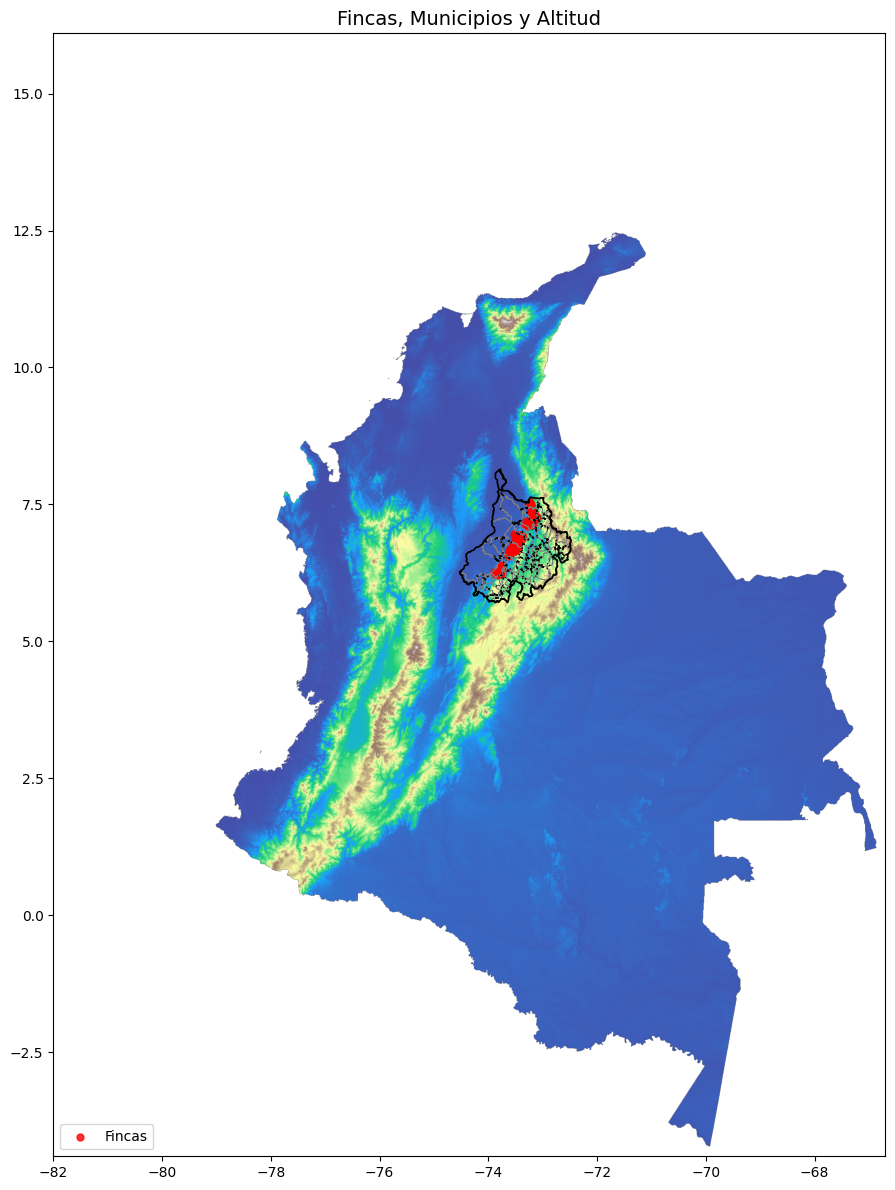

In [16]:
#Mapa final

fig, ax = plt.subplots(figsize=(10, 12))

# Plot DEM
rasterio.plot.show(
    dem,
    ax=ax,
    cmap="terrain",
    alpha=0.9
)

# Plot municipalities
mun_SANT.boundary.plot(
    ax=ax,
    linewidth=0.6,
    edgecolor="gray"
)

# Plot departments
deptos_shp.boundary.plot(
    ax=ax,
    linewidth=1.2,
    edgecolor="black"
)

# Plot occurrences (fincas)
occ.plot(
    ax=ax,
    color="red",
    markersize=25,
    alpha=0.8,
    label="Fincas"
)

# Labels and legend
ax.set_title("Fincas, Municipios y Altitud", fontsize=14)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


In [21]:
#Recortar DEM con municipios seleccionados
from rasterio.mask import mask

# Convert municipalities to GeoJSON
geoms = mun_SANT.geometry.values

dem_clip, transform = mask(
    dem,
    geoms,
    crop=True
)


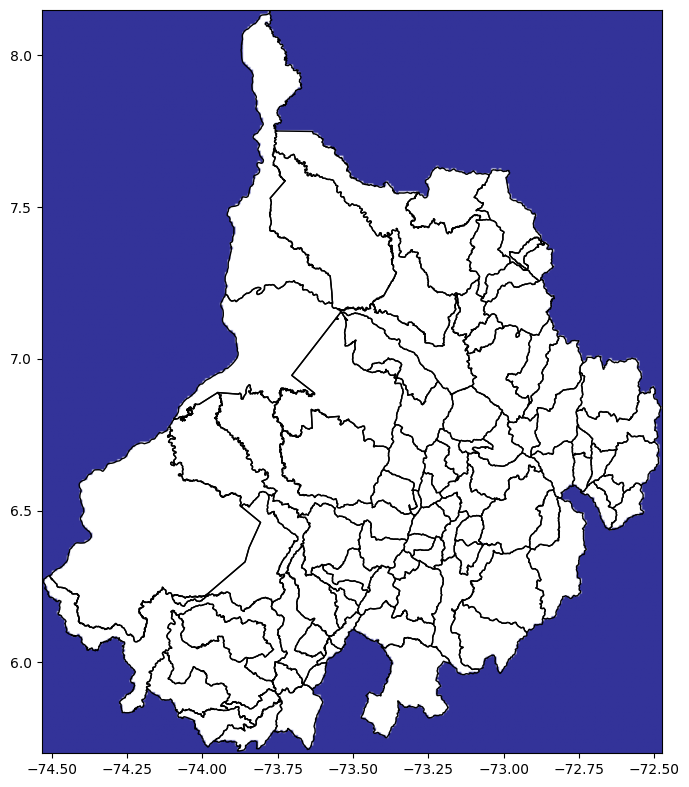

In [22]:
fig, ax = plt.subplots(figsize=(8, 10))

rasterio.plot.show(
    dem_clip,
    transform=transform,
    ax=ax,
    cmap="terrain"
)

mun_SANT.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1
)

plt.show()


In [23]:
if dem_clip.ndim == 3:
    dem_plot = dem_clip[0]
else:
    dem_plot = dem_clip

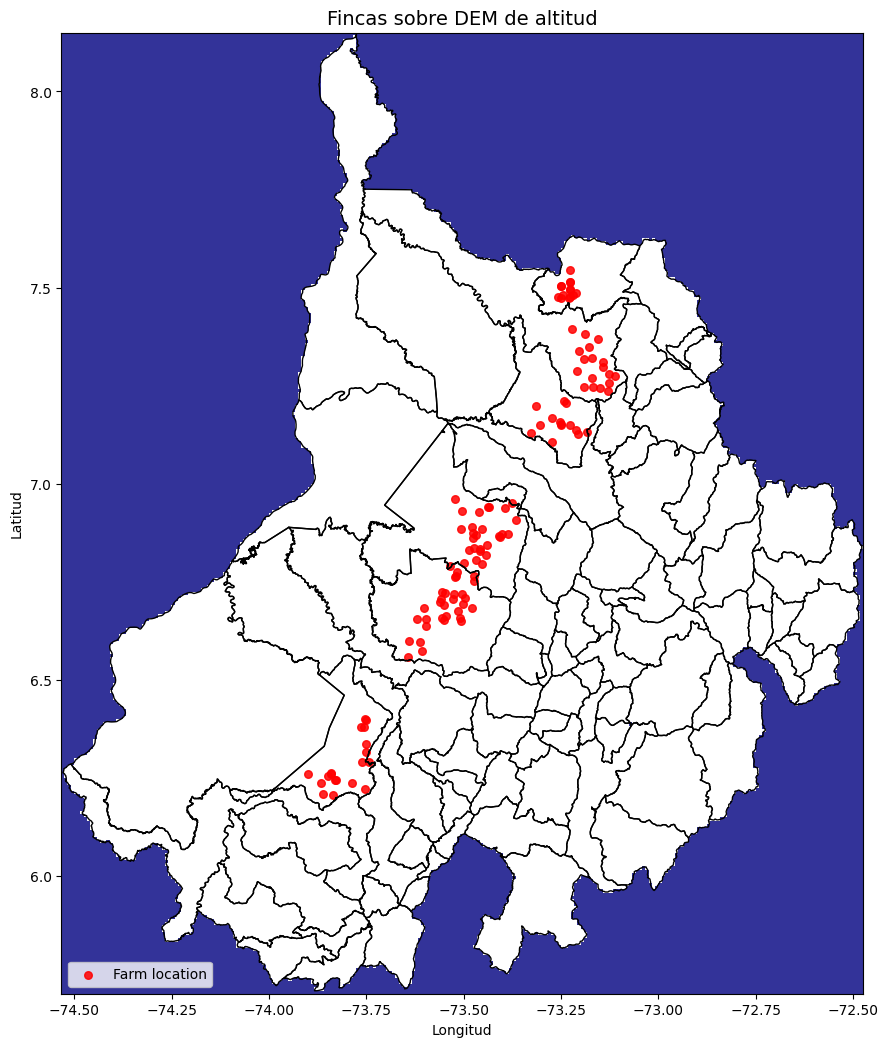

In [30]:
fig, ax = plt.subplots(figsize=(9, 11))

# EJE TRANSPARENTE
ax.set_facecolor("none")

# --- DEM ---
rasterio.plot.show(
    dem_plot,
    transform=transform,
    ax=ax,
    cmap="terrain"
)

# --- Municipios 
mun_SANT.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    zorder=2
)

# --- Fincas ---
occ.plot(
    ax=ax,
    color="red",
    markersize=30,
    alpha=0.85,
    label="Farm location"
)

# --- Layout ---
ax.set_title("Fincas sobre DEM de altitud", fontsize=14)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

ax.legend(loc="lower left")

plt.tight_layout()
plt.show()